# Loan Approval Prediction using Machine Learning

## Objective

The objective of this project is to build a supervised machine learning model that predicts whether a loan application will be approved based on applicant information. The project includes data preprocessing, feature engineering, handling class imbalance, model building, evaluation, and business interpretation.

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset
The loan prediction dataset is loaded into a Pandas DataFrame for analysis.

In [134]:
import os
print(os.listdir())

['.config', 'loan_prediction.csv', 'sample_data']


In [135]:
df = pd.read_csv("loan_prediction.csv")

In [136]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the dataset by checking its dimensions, column names, data types, missing values, and summary statistics.

In [137]:
df.shape

(614, 13)

In [138]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


In [140]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [141]:
df.describe(include='all')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP002990,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


In [142]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [143]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


## Data Cleaning
Missing values are identified and replaced using appropriate statistical techniques such as mode for categorical variables and median for numerical variables.

In [144]:


categorical_columns = ['Gender', 'Married', 'Dependents',
                       'Self_Employed', 'Loan_Amount_Term',
                       'Credit_History']

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

In [145]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


## Data Preprocessing

The Loan_ID column is removed because it is only an identifier. Categorical variables are encoded into numerical values using Label Encoding.

In [146]:
df.drop('Loan_ID', axis=1, inplace=True)

In [147]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [148]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


## Feature Scaling

Feature scaling standardizes numerical values so that all features contribute equally during model training.

In [149]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [150]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

## Train-Test Split

The dataset is divided into training and testing sets to evaluate model performance on unseen data.

In [151]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [152]:

!pip install -q imbalanced-learn

## Handling Class Imbalance

SMOTE (Synthetic Minority Oversampling Technique) is applied to balance the training data by generating synthetic samples for the minority class.

In [153]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

## Model Building - Logistic Regression

A Logistic Regression model is trained as the baseline classifier for predicting loan approval.

In [154]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

## Model Building - Decision Tree

A Decision Tree classifier is trained to learn decision rules from the dataset.

In [155]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

## Model Building - Random Forest

A Random Forest classifier is trained using multiple decision trees to improve prediction accuracy.

In [156]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## Model Evaluation

The trained models are evaluated using Precision, Recall, F1-Score, and ROC-AUC to compare their performance.

In [157]:
from sklearn.metrics import classification_report, roc_auc_score

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_pred_lr))

Logistic Regression
              precision    recall  f1-score   support

           0       0.76      0.51      0.61        43
           1       0.78      0.91      0.84        80

    accuracy                           0.77       123
   macro avg       0.77      0.71      0.73       123
weighted avg       0.77      0.77      0.76       123

ROC AUC: 0.7120639534883721


In [158]:
print("Decision Tree")
print(classification_report(y_test, y_pred_dt))
print("ROC AUC:", roc_auc_score(y_test, y_pred_dt))

Decision Tree
              precision    recall  f1-score   support

           0       0.49      0.49      0.49        43
           1       0.72      0.72      0.72        80

    accuracy                           0.64       123
   macro avg       0.61      0.61      0.61       123
weighted avg       0.64      0.64      0.64       123

ROC AUC: 0.6066860465116279


In [159]:
print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.66      0.44      0.53        43
           1       0.74      0.88      0.80        80

    accuracy                           0.72       123
   macro avg       0.70      0.66      0.67       123
weighted avg       0.71      0.72      0.71       123

ROC AUC: 0.6584302325581395


## Feature Importance

Feature importance is analyzed using the Random Forest model to identify the most influential features affecting loan approval.

In [160]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': df.drop('Loan_Status', axis=1).columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

              Feature  Importance
9      Credit_History    0.206497
5     ApplicantIncome    0.170461
7          LoanAmount    0.166997
6   CoapplicantIncome    0.113994
10      Property_Area    0.106800
2          Dependents    0.068107
1             Married    0.049886
8    Loan_Amount_Term    0.046877
3           Education    0.030659
0              Gender    0.020659
4       Self_Employed    0.019062


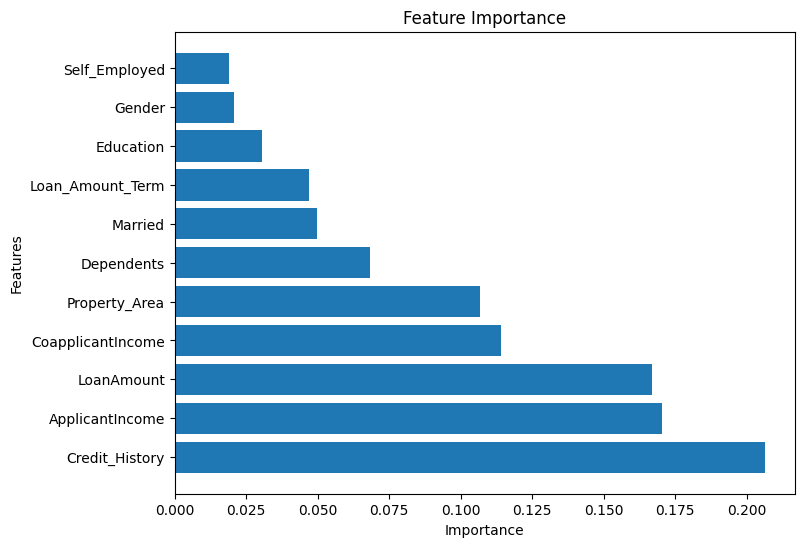

In [161]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.barh(importance['Feature'], importance['Importance'])

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Features")

plt.show()

## Business Interpretation

The developed model helps banks identify applicants who are more likely to repay loans. Features such as Credit History, Applicant Income, Loan Amount, and Property Area have a significant impact on approval decisions.


## Conclusion

This project successfully implemented a complete machine learning pipeline for loan approval prediction, including data preprocessing, handling class imbalance, model training, and evaluation. The best-performing model can be deployed to support faster, more consistent, and data-driven loan approval decisions.